<a href="https://colab.research.google.com/github/ZainabKhan77/ADS2-term-paper/blob/main/TermPaper_ZainabKhan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

data start date: -12603 
data end date: 20453 
total daily observations: 31705 



Call:
lm(formula = TMK ~ date, data = df_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-28.2005  -5.7652   0.0908   5.9550  21.3777 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 9.816e+00  4.665e-02  210.42   <2e-16 ***
date        9.281e-05  4.490e-06   20.67   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.504 on 31703 degrees of freedom
Multiple R-squared:  0.0133,	Adjusted R-squared:  0.01327 
F-statistic: 427.3 on 1 and 31703 DF,  p-value: < 2.2e-16




Table: Average Efficiency of Forecast Models (2-Day Ahead)

|Model                          |   MAE|  RMSE|
|:------------------------------|-----:|-----:|
|Auto ARIMA (Method 1a)         | 2.371| 3.006|
|Fixed ARIMA(2,1,1) (Method 1b) | 2.360| 2.997|
|Holt-Winters (Method 2)        | 2.595| 3.294|

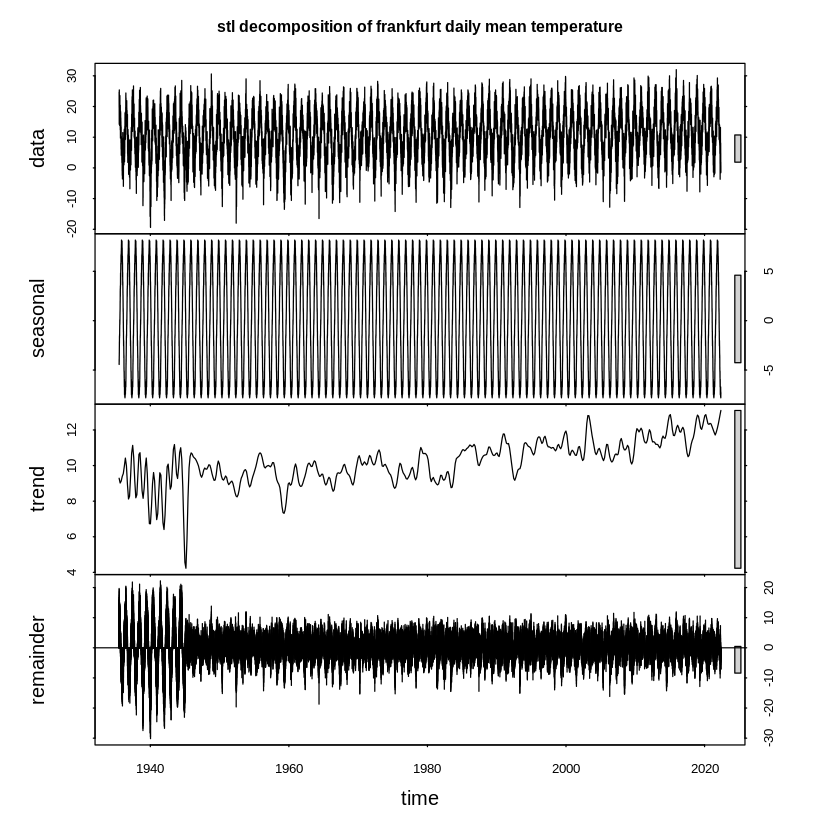

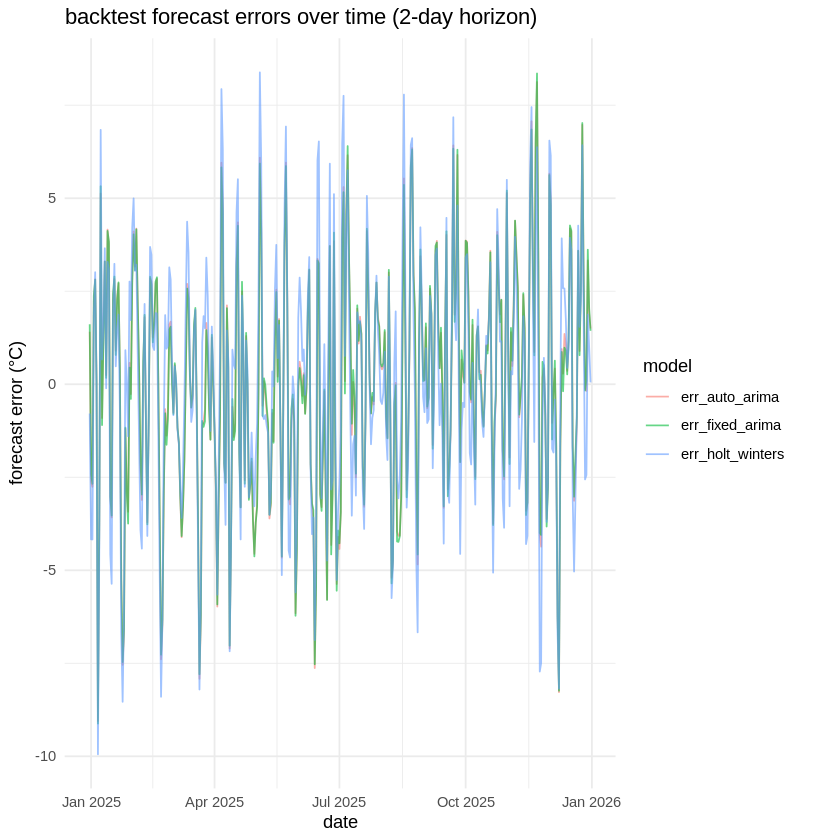

In [6]:
# PART-2

options(warn = -1)

install_if_missing <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org/", dependencies = TRUE)
  }
}

packages <- c("tidyverse", "lubridate", "forecast", "knitr", "ggplot2", "zoo")
invisible(lapply(packages, install_if_missing))

library(tidyverse)
library(lubridate)
library(forecast)
library(knitr)
library(ggplot2)
library(zoo)

# 2. unzip and load uploaded frankfurt climate data

# list files in colab working directory and locate dwd zip or unzipped text file
zip_files <- list.files(pattern = "\\.zip$", full.names = TRUE)

if (length(zip_files) > 0) {
  unzip_files <- unzip(zip_files[1], list = TRUE)
  target_file_in_zip <- unzip_files$Name[grep("^produkt_klima_tag", unzip_files$Name)]
  unzip(zip_files[1], files = target_file_in_zip)
  # After unzipping, the file is in the current directory. Get its full path.
  data_filename <- list.files(pattern = "^produkt_klima_tag", full.names = TRUE)[1]
} else {
  data_filename <- list.files(pattern = "^produkt_klima_tag", full.names = TRUE)[1]
}

raw_data <- read.table(data_filename, header = TRUE, sep = ";", strip.white = TRUE, stringsAsFactors = FALSE)

# 3. data quality check, cleaning, and granularity verification

# check for missing values (-999 in dwd format) and verify daily frequency
df_clean <- raw_data %>%
  rename(date = MESS_DATUM, TMK = TMK) %>%
  mutate(
    date = ymd(as.character(date)),
    # replace dwd missing value code -999 with NA
    TMK = ifelse(TMK == -999, NA, TMK)
  ) %>%
  filter(!is.na(TMK)) %>%
  select(date, TMK) %>%
  arrange(date)

# confirm granularity (daily observations summary)
cat("data start date:", min(df_clean$date), "\n")
cat("data end date:", max(df_clean$date), "\n")
cat("total daily observations:", nrow(df_clean), "\n")

# 4. trend and seasonality analysis

# create time series object with annual (365.25) and weekly (7) frequency
tmk_ts_annual <- ts(df_clean$TMK, frequency = 365, start = c(year(min(df_clean$date)), yday(min(df_clean$date))))

# stl decomposition for annual seasonality and long term trend
stl_decomp <- stl(tmk_ts_annual, s.window = "periodic")
plot(stl_decomp, main = "stl decomposition of frankfurt daily mean temperature")

# check linear trend over time
trend_model <- lm(TMK ~ date, data = df_clean)
summary(trend_model)

# 5. forecast & backtest cycle (2-day prediction horizon)

# learning history window (evaluating on last 2 years of observations for colab performance)
eval_data <- df_clean %>% filter(date >= max(date) - years(2))

window_size <- 365 # 1 year initial learning history window
n_obs <- nrow(eval_data)
horizon <- 2       # 2-day ahead forecast requirement

# vectors to store backtest forecast errors (prediction - realized)
errors_arima_auto <- numeric()
errors_arima_fixed <- numeric()
errors_hw <- numeric()
dates_recorded <- as.Date(character())

# backtest loop: shift time series by 1 observation into direction of today
for (i in 1:(n_obs - window_size - horizon + 1)) {

  # expanding training window
  train_df <- eval_data[1:(window_size + i - 1), ]
  actual_2day <- eval_data$TMK[window_size + i + horizon - 1]
  current_date <- eval_data$date[window_size + i + horizon - 1]

  ts_train <- ts(train_df$TMK, frequency = 7) # 7-day weekly seasonality

  # model 1 (method 1a): auto arima
  fit_auto <- auto.arima(ts_train, seasonal = FALSE, approximation = TRUE, trace = FALSE)
  fc_auto <- forecast(fit_auto, h = horizon)$mean[horizon]

  # model 2 (method 1b): parameterization 2 - fixed arima(2,1,1)
  fit_fixed <- Arima(ts_train, order = c(2,1,1))
  fc_fixed <- forecast(fit_fixed, h = horizon)$mean[horizon]

  # model 3 (method 2): structurally different method - holt-winters exponential smoothing
  fit_hw <- HoltWinters(ts_train, gamma = FALSE)
  fc_hw <- predict(fit_hw, n.ahead = horizon)[horizon]

  # record errors (forecast - actual realized)
  errors_arima_auto <- c(errors_arima_auto, fc_auto - actual_2day)
  errors_arima_fixed <- c(errors_arima_fixed, fc_fixed - actual_2day)
  errors_hw <- c(errors_hw, fc_hw - actual_2day)
  dates_recorded <- c(dates_recorded, current_date)
}

# 6. store backtest results & produce error comparison

results_df <- data.frame(
  date = dates_recorded,
  err_auto_arima = errors_arima_auto,
  err_fixed_arima = errors_arima_fixed,
  err_holt_winters = errors_hw
)

# average efficiency (mae and rmse) table across models
efficiency_summary <- data.frame(
  Model = c("Auto ARIMA (Method 1a)", "Fixed ARIMA(2,1,1) (Method 1b)", "Holt-Winters (Method 2)"),
  MAE = c(mean(abs(results_df$err_auto_arima)),
          mean(abs(results_df$err_fixed_arima)),
          mean(abs(results_df$err_holt_winters))),
  RMSE = c(sqrt(mean(results_df$err_auto_arima^2)),
           sqrt(mean(results_df$err_fixed_arima^2)),
           sqrt(mean(results_df$err_holt_winters^2)))
)

kable(efficiency_summary, caption = "Average Efficiency of Forecast Models (2-Day Ahead)", digits = 3)

# 7. plot forecast errors over time

results_df %>%
  pivot_longer(cols = starts_with("err_"), names_to = "Model", values_to = "Error") %>%
  ggplot(aes(x = date, y = Error, color = Model)) +
  geom_line(alpha = 0.6) +
  theme_minimal() +
  labs(title = "backtest forecast errors over time (2-day horizon)",
       x = "date", y = "forecast error (°C)", color = "model")